<a href="https://colab.research.google.com/github/ankitha-km/AI_using_colab/blob/main/customer_segmentation_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

np.random.seed(42)
random.seed(42)

print("All libraries imported!")

All libraries imported!


In [ ]:
n_customers = 2847
today = datetime(2024, 12 , 31)

n_customers = 2847
today = datetime(2024, 12, 31)

data = {
    'customer_id': ['C-' + str(i).zfill(4) for i in range(1, n_customers + 1)],
    'recency': np.random.exponential(scale=60, size=n_customers).astype(int) + 1,
    'frequency': np.random.negative_binomial(n=5, p=0.5, size=n_customers) + 1,
    'monetary': np.random.lognormal(mean=9, sigma=1, size=n_customers).astype(int),
    'support_tickets': np.random.poisson(lam=1.5, size=n_customers),
    'tenure_days': np.random.randint(30, 1500, size=n_customers),
    'avg_order_value': np.random.lognormal(mean=7, sigma=0.8, size=n_customers).astype(int),
}

df = pd.DataFrame(data)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2847, 7)

First 5 rows:


,customer_id,recency,frequency,monetary,support_tickets,tenure_days,avg_order_value
0,C-0001,29,5,12033,2,662,582
1,C-0002,181,2,27241,3,115,1745
2,C-0003,80,6,3575,1,128,1659
3,C-0004,55,10,1060,0,403,294
4,C-0005,11,5,4923,0,787,1546


In [ ]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Basic Statistics ===")
print(df.describe().round(2))

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2847 entries, 0 to 2846
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      2847 non-null   object
 1   recency          2847 non-null   int64 
 2   frequency        2847 non-null   int64 
 3   monetary         2847 non-null   int64 
 4   support_tickets  2847 non-null   int64 
 5   tenure_days      2847 non-null   int64 
 6   avg_order_value  2847 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 155.8+ KB
None

=== Basic Statistics ===
       recency  frequency   monetary  support_tickets  tenure_days  \
count  2847.00    2847.00    2847.00          2847.00      2847.00   
mean     60.64       6.02   12933.24             1.49       757.11   
std      60.13       3.19   15565.69             1.23       422.26   
min       1.00       1.00     209.00             0.00        30.00   
25%      17.00       4.00    3970.0

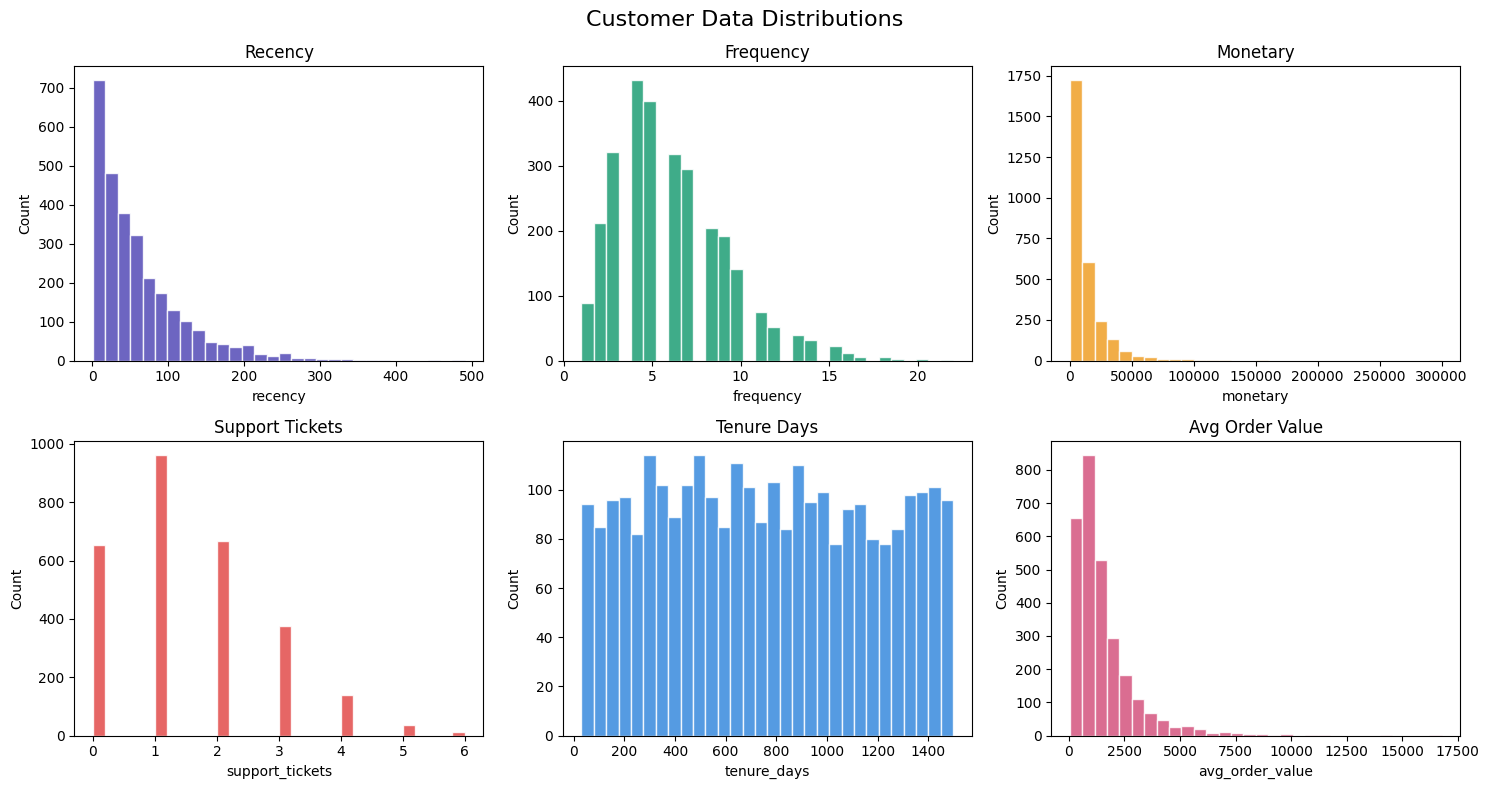

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Customer Data Distributions', fontsize=16)

columns = ['recency', 'frequency', 'monetary', 'support_tickets', 'tenure_days', 'avg_order_value']
colors = ['#534AB7', '#1D9E75', '#EF9F27', '#E24B4A', '#378ADD', '#D4537E']

for i, (col, color) in enumerate(zip(columns, colors)):
    row, col_idx = i // 3, i % 3
    axes[row][col_idx].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[row][col_idx].set_title(col.replace('_', ' ').title())
    axes[row][col_idx].set_xlabel(col)
    axes[row][col_idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Score each customer 1-5 on Recency, Frequency, Monetary

# Recency: lower days = better = higher score
df['R_score'] = pd.qcut(df['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher orders = better = higher score
df['F_score'] = pd.qcut(df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher spend = better = higher score
df['M_score'] = pd.qcut(df['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM score
df['RFM_score'] = df['R_score'] + df['F_score'] + df['M_score']

print("RFM Scores added!")
print(df[['customer_id', 'R_score', 'F_score', 'M_score', 'RFM_score']].head(10))

RFM Scores added!
  customer_id  R_score  F_score  M_score  RFM_score
0      C-0001        4        2        4         10
1      C-0002        1        1        5          7
2      C-0003        2        3        2          7
3      C-0004        3        5        1          9
4      C-0005        5        2        2          9
5      C-0006        5        3        5         13
6      C-0007        5        1        1          7
7      C-0008        1        1        1          3
8      C-0009        3        3        3          9
9      C-0010        2        1        3          6


In [ ]:
# Segment based on RFM score
def assign_segment(row):
    score = row['RFM_score']
    if score >= 12:
        return 'Champion'
    elif score >= 9:
        return 'Loyal'
    elif score >= 6:
        return 'At-risk'
    else:
        return 'Lost'

df['segment'] = df.apply(assign_segment, axis=1)

print("=== Segment Distribution ===")
print(df['segment'].value_counts())
print("\nPercentage:")
print(df['segment'].value_counts(normalize=True).mul(100).round(1))

=== Segment Distribution ===
segment
Loyal       1188
At-risk      964
Champion     457
Lost         238
Name: count, dtype: int64

Percentage:
segment
Loyal       41.7
At-risk     33.9
Champion    16.1
Lost         8.4
Name: proportion, dtype: float64


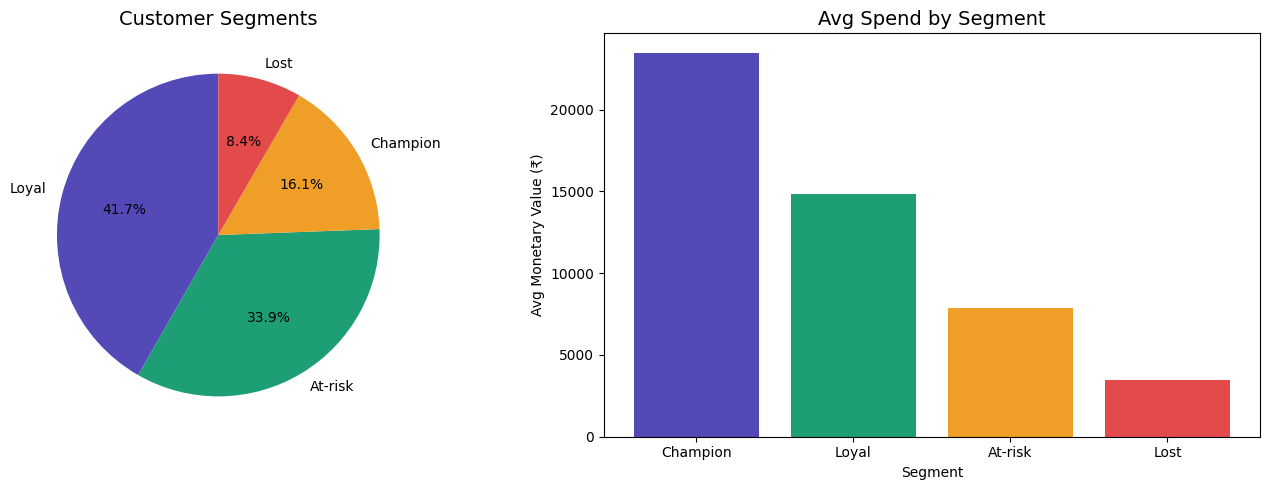

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#534AB7', '#1D9E75', '#EF9F27', '#E24B4A']

# Pie chart
segment_counts = df['segment'].value_counts()
axes[0].pie(segment_counts, labels=segment_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Customer Segments', fontsize=14)

# Bar chart - avg monetary by segment
segment_avg = df.groupby('segment')['monetary'].mean().sort_values(ascending=False)
axes[1].bar(segment_avg.index, segment_avg.values, color=colors)
axes[1].set_title('Avg Spend by Segment', fontsize=14)
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Monetary Value (₹)')

plt.tight_layout()
plt.show()

In [ ]:
# Create churn label based on business logic
# High recency + low frequency + low RFM = churned

def create_churn_label(row):
    if row['segment'] == 'Lost':
        return np.random.choice([0, 1], p=[0.08, 0.92])
    elif row['segment'] == 'At-risk':
        return np.random.choice([0, 1], p=[0.32, 0.68])
    elif row['segment'] == 'Loyal':
        return np.random.choice([0, 1], p=[0.89, 0.11])
    else:  # Champion
        return np.random.choice([0, 1], p=[0.97, 0.03])

df['churn'] = df.apply(create_churn_label, axis=1)

print("=== Churn Distribution ===")
print(df['churn'].value_counts())
print("\nChurn Rate:", round(df['churn'].mean() * 100, 2), "%")

=== Churn Distribution ===
churn
0    1710
1    1137
Name: count, dtype: int64

Churn Rate: 39.94 %


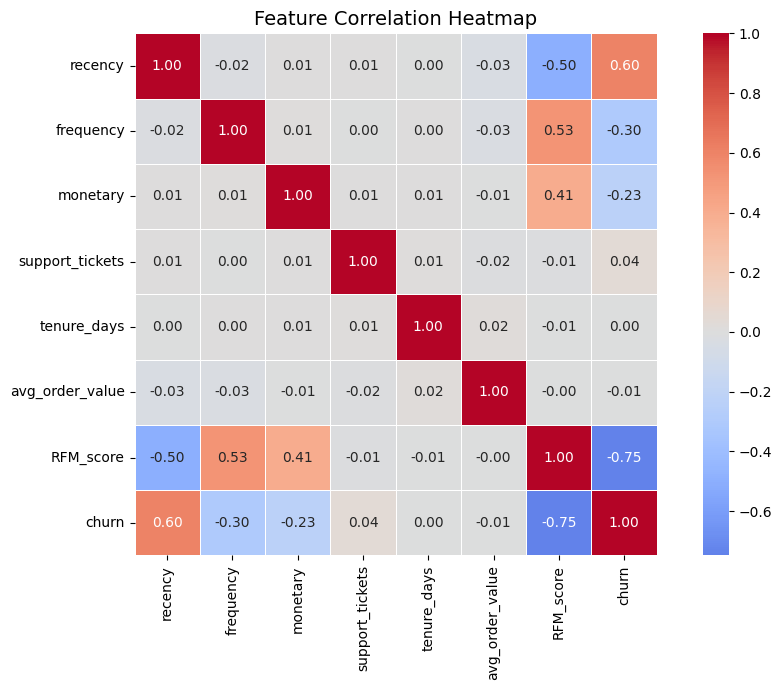

In [ ]:
plt.figure(figsize=(10, 7))

corr_cols = ['recency', 'frequency', 'monetary', 'support_tickets',
             'tenure_days', 'avg_order_value', 'RFM_score', 'churn']

corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Features and target
features = ['recency', 'frequency', 'monetary', 'support_tickets',
            'tenure_days', 'avg_order_value', 'R_score', 'F_score', 'M_score']

X = df[features]
y = df['churn']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nChurn rate in training set:", round(y_train.mean() * 100, 2), "%")
print("Churn rate in test set:", round(y_test.mean() * 100, 2), "%")

Training samples: 2277
Testing samples: 570

Churn rate in training set: 39.92 %
Churn rate in test set: 40.0 %


training model using random forest


In [ ]:
# Train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Model Performance ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Model Performance ===
Accuracy: 99.3 %
ROC-AUC Score: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       342
           1       1.00      0.98      0.99       228

    accuracy                           0.99       570
   macro avg       0.99      0.99      0.99       570
weighted avg       0.99      0.99      0.99       570



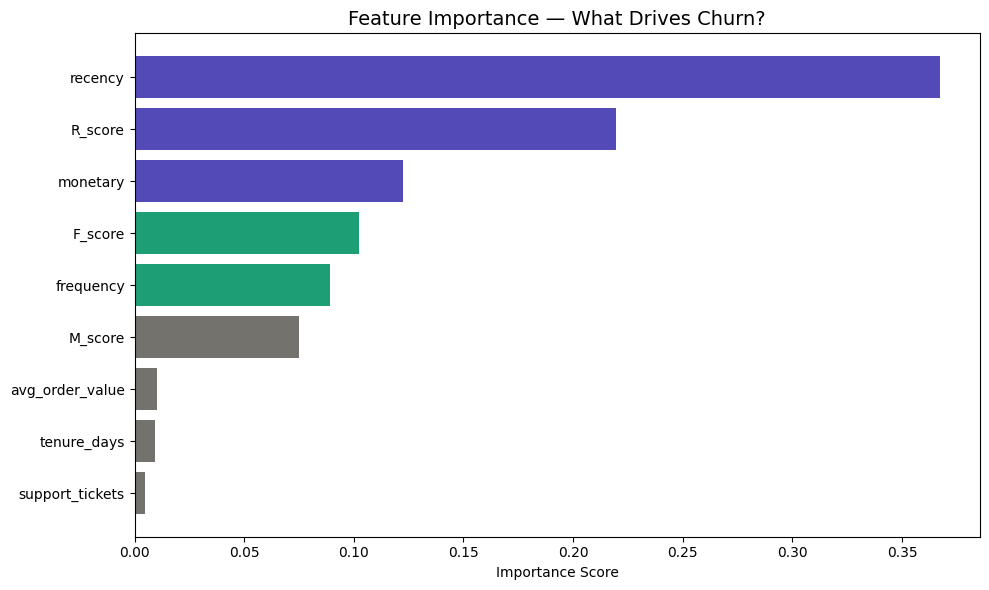

           feature  importance
0          recency    0.367216
6          R_score    0.219756
2         monetary    0.122561
7          F_score    0.102403
1        frequency    0.089169
8          M_score    0.074899
5  avg_order_value    0.010209
4      tenure_days    0.009191
3  support_tickets    0.004595


In [ ]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#534AB7' if i < 3 else '#1D9E75' if i < 5 else '#73726c'
          for i in range(len(feature_importance))]

plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance — What Drives Churn?', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance)

confusion matrix


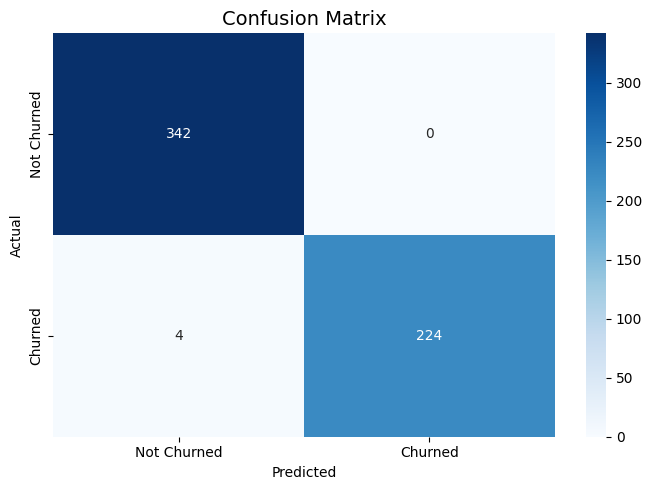

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

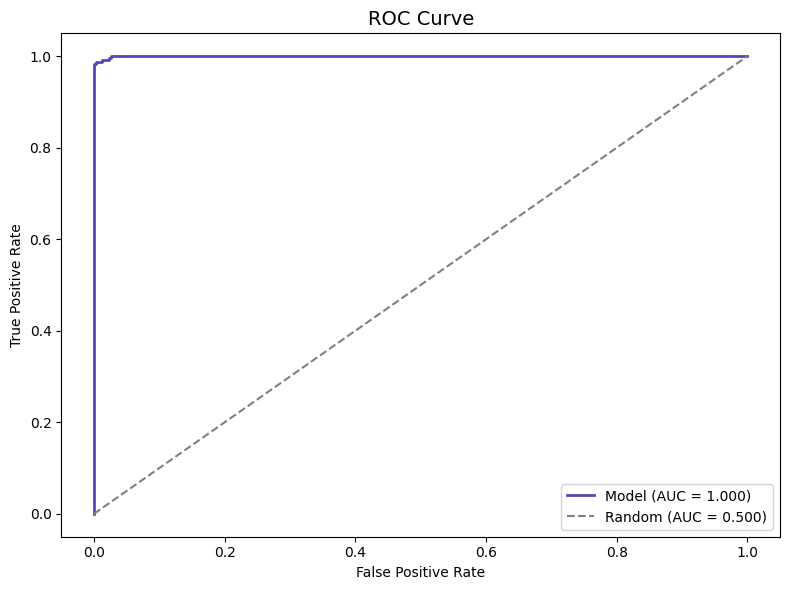

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#534AB7', lw=2, label=f'Model (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Predict churn for a new customer
def predict_churn(recency, frequency, monetary, support_tickets,
                  tenure_days, avg_order_value, r_score, f_score, m_score):

    customer = pd.DataFrame([[recency, frequency, monetary, support_tickets,
                               tenure_days, avg_order_value, r_score, f_score, m_score]],
                             columns=features)

    prob = rf_model.predict_proba(customer)[0][1]
    label = "WILL CHURN" if prob > 0.5 else "WILL NOT CHURN"

    print(f"Churn Probability : {round(prob * 100, 2)}%")
    print(f"Prediction        : {label}")

    if prob > 0.7:
        print("Action            : Send win-back email with 20% discount immediately!")
    elif prob > 0.4:
        print("Action            : Send personalised re-engagement campaign")
    else:
        print("Action            : Customer is healthy — keep nurturing")

# Test it
predict_churn(
    recency=85,
    frequency=3,
    monetary=5000,
    support_tickets=4,
    tenure_days=200,
    avg_order_value=1200,
    r_score=2,
    f_score=2,
    m_score=2
)

Churn Probability : 99.0%
Prediction        : WILL CHURN
Action            : Send win-back email with 20% discount immediately!


In [ ]:
import pickle

# Save the dataset
df.to_csv('customers.csv', index=False)
print("Dataset saved as customers.csv")

# Save the model
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("Model saved as churn_model.pkl")

print("\nFinal dataset shape:", df.shape)
print("Columns:", list(df.columns))

Dataset saved as customers.csv
Model saved as churn_model.pkl

Final dataset shape: (2847, 13)
Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'support_tickets', 'tenure_days', 'avg_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'segment', 'churn']
